# Clasificación de Especies de Pinguinos mediante Random Forest

### Carga de librerías requeridas


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.model_selection import (KFold, StratifiedKFold,
                                     RepeatedStratifiedKFold, cross_val_score,
                                     GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                         f1_score, balanced_accuracy_score,
                          confusion_matrix, ConfusionMatrixDisplay, classification_report)




### Carga de datos


In [3]:
pinwinos = pd.read_csv('PinwinosPalmerLimpia.csv')
pinwinos.head()

,Especie,Isla,Sexo,Anio,Longitud_Pico_cm,Profundidad_Pico_cm,Longitud_Aleta_cm,Masa_Corporal_kg
0,Adelie,Torgersen,Macho,2007,3.91,1.87,18.1,3.75
1,Adelie,Torgersen,Hembra,2007,3.95,1.74,18.6,3.80
2,Adelie,Torgersen,Hembra,2007,4.03,1.80,19.5,3.25
3,Adelie,Torgersen,Hembra,2007,3.88,1.83,19.0,3.70
4,Adelie,Torgersen,Hembra,2007,3.67,1.93,19.3,3.45


###  Modelo Random Forest



Los modelos Random Forest suelen ser muy útiles para ejercicios de clasificación y regresión. Consisten en construir un gran número de árboles de decisión donde cada árbol se entrena con una muestra aleatoria de los datos, y el resultado final se obtiene agregando las predicciones de todos los árboles (en el caso de la clasificación se toma la moda). Algunas de sus ventajas es que es robusto frente a datos faltantes y a datos outliers, su riesgo de sobreajuste es menor que el de un árbol de decisión, son capaces de evaluar que variables aportan más información, entre otras.

Por otro lado, estos modelos tienen es que puede ser díficil de interpretar cuando se tiene muchas variables predictoras, tienden al sobreajuste cuando no se "podan", y suelen tener un mejor desempeño en bases de datos grandes.



Como se explico anteriormente, este modelo suele ser robusto frente a varialbes outliers por lo que las conservaremos.

#### Checamos cómo está distribuida nuestra variable objetivo

In [4]:
balance = pinwinos.Especie.value_counts().rename_axis('Especies').reset_index(name='counts')
total_balance = balance['counts'].sum()
balance['%'] = (balance['counts'] /total_balance * 100)
balance

,Especies,counts,%
0,Adelie,152,44.186047
1,Gentoo,124,36.046512
2,Chinstrap,68,19.767442


Observamos que los valores no presentan un gran desbalanceo por lo que no realizaremos algún balance de la base

### Definimos la varaible objertivo y las variables predictoras

Tomamos las varaibles: Isla, Longitud_Pico_cm, Profundidad_Pico_cm, Longitud_Aleta_cm, Masa_Corporal_kg, como variables predictores y excluimos Anio, Sexo e Isla, ya que no son variables corporales.


In [5]:
X = pinwinos[[ "Longitud_Pico_cm", "Profundidad_Pico_cm", "Longitud_Aleta_cm", "Masa_Corporal_kg"]]
X = pd.get_dummies(X)
Y = pinwinos["Especie"]


###

Para obtener una estimación robusta, implementamos un esquema de validación cruzada anidada.

Usamos StratifiedKFold, para mantener la proporción de las 3 clases en nuestra variable objetivo (Especie: Adelie, Gentoo y Chinstrap).


*  Outer Loop: Empleamos validación cruzada estratificada en 5 folds, en cada iteración se usa aproximadamente el 80% de las observaciones para entrenamiento y 20% para la evaluación fuera de muestra

*   Inner Loop: Dentro de cada fold de entrenamiento del outer loop, implementamos una segunda validación cruzada estratificada de 3 folds, para la selección de hiperparámetros por medio de GridSearchCV

Usaremos estratificación (stratify = y) porque nuestra variable objetivo (Especie) tiene varias categorías, y de esta manera se mantienen las proporciones.






In [6]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


pipe_rf = Pipeline([
    ('model', RandomForestClassifier(random_state=42)) # definimos el modelo
])

# Definimos varias opciones de hiperparámetros
param_grid = {
    'model__n_estimators': [100, 300, 500], # número de árboles
    'model__max_depth': [None, 3, 5, 7], # profundidad máxima del árbol
    'model__min_samples_split': [2, 5, 10],
     'model__min_samples_leaf': [1, 3, 5]
}

# outer loop
outer_cv = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42)

inner_cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = 42)

# Validaciones

nested_scores = []
y_true_acum = []
y_pred_acum = []


for train_idx, test_idx in outer_cv.split(X, Y):
    X_tr = X.iloc[train_idx]
    X_te = X.iloc[test_idx]
    y_tr = Y.iloc[train_idx]
    y_te = Y.iloc[test_idx]

    gs = GridSearchCV(estimator = pipe_rf,
                      param_grid = param_grid , cv=inner_cv, scoring='accuracy', n_jobs=-1)
    gs.fit(X_tr, y_tr)

    best_model = gs.best_estimator_

    y_pred = best_model.predict(X_te)

    y_true_acum.extend(y_te)
    y_pred_acum.extend(y_pred)

    nested_scores.append(accuracy_score(y_te, y_pred))

print(f"Nested CV Accuracy: {np.mean(nested_scores):.4f} ± {np.std(nested_scores):.4f}")


grid = GridSearchCV(estimator = pipe_rf, param_grid = param_grid, cv=inner_cv, scoring='accuracy', verbose=1, n_jobs = -1)
grid.fit(X_tr, y_tr)

best_rf = grid.best_estimator_
print("\nMejores hiperparámetros:", grid.best_params_)
print(f"Mejor accuracy CV: {grid.best_score_:.4f}")


Nested CV Accuracy: 0.9739 ± 0.0266
Fitting 3 folds for each of 108 candidates, totalling 324 fits

Mejores hiperparámetros: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Mejor accuracy CV: 0.9746


### Matriz de Confusión

[[148   4   0]
 [  4  64   0]
 [  0   1 123]]


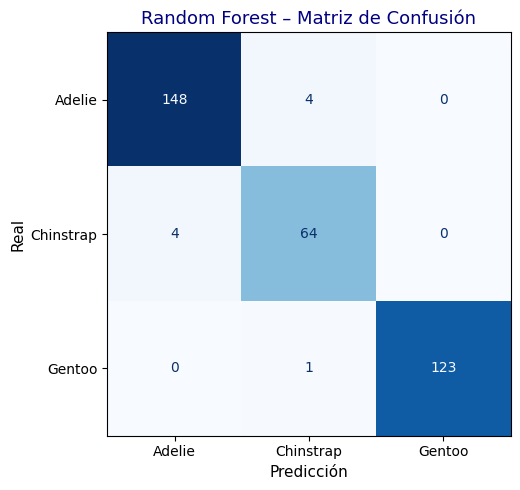

In [7]:

cm = confusion_matrix(y_true_acum, y_pred_acum)
print(cm)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_true_acum,
                                        y_pred_acum,
                                        ax = ax,
                                         colorbar=False,
                                      cmap="Blues"
                                          )
ax.set_title("Random Forest – Matriz de Confusión", fontsize=13, color = "navy")
ax.set_xlabel("Predicción", fontsize=11)
ax.set_ylabel("Real", fontsize=11)

plt.tight_layout()
plt.savefig("01_Matriz_Random_Forest.png", dpi=150)
plt.show()
plt.close()


In [8]:
print(classification_report(y_true_acum, y_pred_acum))

              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97       152
   Chinstrap       0.93      0.94      0.93        68
      Gentoo       1.00      0.99      1.00       124

    accuracy                           0.97       344
   macro avg       0.97      0.97      0.97       344
weighted avg       0.97      0.97      0.97       344



### Métricas Globales

In [10]:
print("\n=== Métricas detalladas ===")
print(f"Accuracy:           {accuracy_score(y_true_acum, y_pred_acum):.4f}")
print(f"Precision (macro):  {precision_score(y_true_acum, y_pred_acum, average='macro'):.4f}")
print(f"Recall (macro):     {recall_score(y_true_acum, y_pred_acum, average='macro'):.4f}")
print(f"F1-Score (macro):   {f1_score(y_true_acum, y_pred_acum, average='macro'):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_true_acum, y_pred_acum):.4f}")


resultado_1 = {
    "accuracy":np.mean(accuracy_score(y_true_acum, y_pred_acum)),
    "precision":np.mean(precision_score(y_true_acum, y_pred_acum, average='macro')),
    "Recall (macro)":np.mean(recall_score(y_true_acum, y_pred_acum, average='macro')),
    "F1-Score (macro)":np.mean(f1_score(y_true_acum, y_pred_acum, average='macro')),
"Balanced Accuracy":np.mean(balanced_accuracy_score(y_true_acum, y_pred_acum))
}



=== Métricas detalladas ===
Accuracy:           0.9738
Precision (macro):  0.9671
Recall (macro):     0.9689
F1-Score (macro):   0.9680
Balanced Accuracy:  0.9689


Podemos ver que el modelo presenta una exactitud promedio de 97.38% bajo el esquema de validación cruzada anidada. Los hiperparámetros seleccionados mediante GridSearchCV corresponden a árboles sin restricción de profundidad ( max_depth = None), con un tamaño mínimo de hoja de 1 observación y un mínimo de 2 observaciones para realizar particiones.

Además la baja variablididad (±2.66%) indica que nuestro modelo es estable y consistente. La matriz de confusión muestra 9 observaciones clasificadas incorrectamente, por lo que este modelo tiene una capacidad de clasificación de la varaible objetivo adecuada.



### Importancia de las variables

In [11]:
importancia = best_rf.named_steps['model'].feature_importances_

pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancia}).sort_values('Importancia', ascending = False)

,Variable,Importancia
0,Longitud_Pico_cm,0.373978
2,Longitud_Aleta_cm,0.312750
1,Profundidad_Pico_cm,0.216650
3,Masa_Corporal_kg,0.096622



Tenemos que las variables con mayor importancia son:

    Longitud_Pico_cm
    Profundidad_Pico_cm
    Longitud_Aleta_cm

Por lo que, podemos concluir que el ajuste del modelo no depende de una sola variable predictora, si no de la combinación de múltiples variables. Aunque la variable "Masa_Corporal_kg" es la que menos inormación aporta.


### Random Forest (con restricciones)

Sin embargo, ya que los hiperparámetros seleccionados corresponden a árboles altamente flexibles, realizaremos un ejercicio en el cuál restringimos la complejidad del modelo para evaluar la robustez de los resultados y descartar posibles efectos de sobreajuste (pre-poda).

In [12]:
pipe_rf = Pipeline([
    ('model', RandomForestClassifier(random_state=42)) # definimos el modelo
])

# Definimos varias opciones de hiperparámetros
param_grid = {
    'model__n_estimators': [100, 300, 500], # número de árboles
    'model__max_depth': [3, 5, 7], # profundidad máxima del árbol
    'model__min_samples_split': [5, 10,20],
     'model__min_samples_leaf': [3, 5, 10] }

# outer loop
outer_cv = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42)

inner_cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = 42)

# Validaciones

nested_scores = []
y_true_acum = []
y_pred_acum = []


for train_idx, test_idx in outer_cv.split(X, Y):
    X_tr = X.iloc[train_idx]
    X_te = X.iloc[test_idx]
    y_tr = Y.iloc[train_idx]
    y_te = Y.iloc[test_idx]

    gs = GridSearchCV(estimator = pipe_rf,
                      param_grid = param_grid , cv=inner_cv, scoring='accuracy', n_jobs=-1)
    gs.fit(X_tr, y_tr)

    best_model = gs.best_estimator_

    y_pred = best_model.predict(X_te)

    y_true_acum.extend(y_te)
    y_pred_acum.extend(y_pred)

    nested_scores.append(accuracy_score(y_te, y_pred))

print(f"Nested CV Accuracy: {np.mean(nested_scores):.4f} ± {np.std(nested_scores):.4f}")


grid = GridSearchCV(estimator = pipe_rf, param_grid = param_grid, cv=inner_cv, scoring='accuracy', verbose=1, n_jobs = -1)
grid.fit(X_tr, y_tr)

best_rf2 = grid.best_estimator_
print("\nMejores hiperparámetros:", grid.best_params_)
print(f"Mejor accuracy CV: {grid.best_score_:.4f}")

Nested CV Accuracy: 0.9739 ± 0.0266
Fitting 3 folds for each of 81 candidates, totalling 243 fits

Mejores hiperparámetros: {'model__max_depth': 5, 'model__min_samples_leaf': 3, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Mejor accuracy CV: 0.9674


### Importancia de las variables

Observamos que la importancia asignada a cada variable es muy parecida a los valores del modelo anterior

In [13]:
importancia = best_rf2.named_steps['model'].feature_importances_

pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancia}).sort_values('Importancia', ascending = False)

,Variable,Importancia
0,Longitud_Pico_cm,0.361816
2,Longitud_Aleta_cm,0.328242
1,Profundidad_Pico_cm,0.204085
3,Masa_Corporal_kg,0.105857


[[148   4   0]
 [  4  64   0]
 [  0   1 123]]


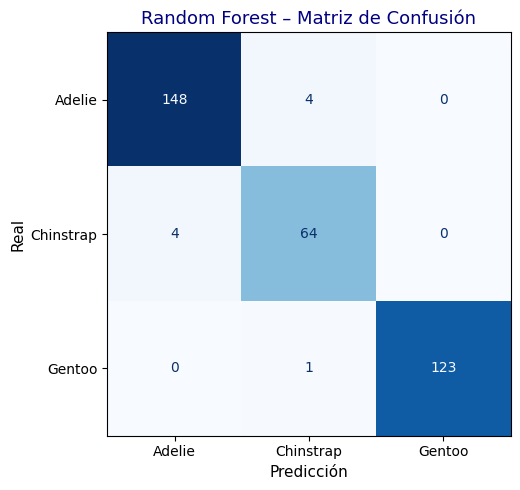

In [14]:
cm1 = confusion_matrix(y_true_acum, y_pred_acum)
print(cm1)
fig, ax = plt.subplots(figsize=(6, 5))
mod_2= ConfusionMatrixDisplay.from_predictions(y_true_acum,
                                        y_pred_acum,
                                        ax = ax,
                                         colorbar=False,
                                      cmap="Blues"
                                          )
ax.set_title("Random Forest – Matriz de Confusión", fontsize=13, color = "navy")
ax.set_xlabel("Predicción", fontsize=11)
ax.set_ylabel("Real", fontsize=11)

plt.tight_layout()
plt.savefig("01_Matriz_Random_Forest.png", dpi=150)
plt.show()
plt.close()

In [15]:
print(classification_report(y_true_acum, y_pred_acum))

              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97       152
   Chinstrap       0.93      0.94      0.93        68
      Gentoo       1.00      0.99      1.00       124

    accuracy                           0.97       344
   macro avg       0.97      0.97      0.97       344
weighted avg       0.97      0.97      0.97       344



In [16]:
print("\n=== Métricas detalladas ===")
print(f"Accuracy:           {accuracy_score(y_true_acum, y_pred_acum):.4f}")
print(f"Precision (macro):  {precision_score(y_true_acum, y_pred_acum, average='macro'):.4f}")
print(f"Recall (macro):     {recall_score(y_true_acum, y_pred_acum, average='macro'):.4f}")
print(f"F1-Score (macro):   {f1_score(y_true_acum, y_pred_acum, average='macro'):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_true_acum, y_pred_acum):.4f}")

resultado_2 = {
    "accuracy":np.mean(accuracy_score(y_true_acum, y_pred_acum)),
    "precision":np.mean(precision_score(y_true_acum, y_pred_acum, average='macro')),
    "Recall (macro)":np.mean(recall_score(y_true_acum, y_pred_acum, average='macro')),
    "F1-Score (macro)":np.mean(f1_score(y_true_acum, y_pred_acum, average='macro')),
"Balanced Accuracy":np.mean(balanced_accuracy_score(y_true_acum, y_pred_acum))
}


=== Métricas detalladas ===
Accuracy:           0.9738
Precision (macro):  0.9671
Recall (macro):     0.9689
F1-Score (macro):   0.9680
Balanced Accuracy:  0.9689


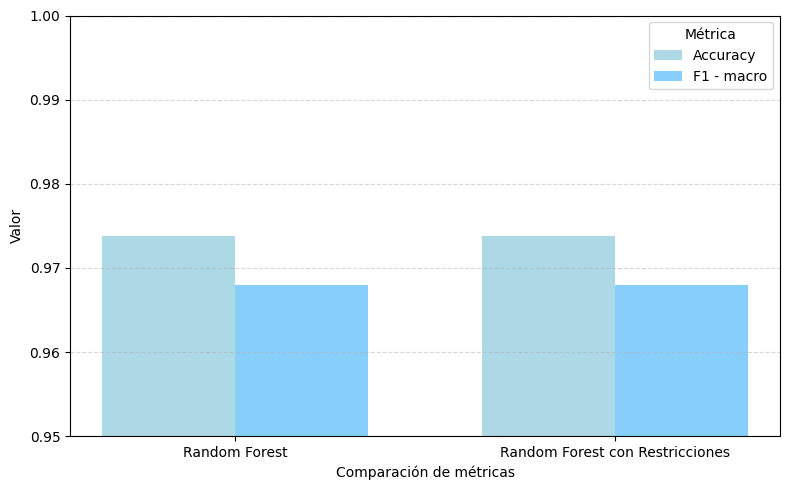

<Figure size 640x480 with 0 Axes>

In [17]:
modelos = ["Random Forest", "Random Forest con Restricciones"]

accuracy = [
    resultado_1["accuracy"],
    resultado_2["accuracy"],
]

f1= [
    resultado_1["F1-Score (macro)"],
    resultado_2["F1-Score (macro)"],
]

x = np.arange(len(modelos))
width = 0.35

plt.figure(figsize=(8,5))


plt.bar(x-width/2, accuracy, width,
        label = "Accuracy", color="lightblue" )

plt.bar(x+width/2, f1, width,
        label = "F1 - macro", color= "lightskyblue")

plt.xticks(x,modelos)

plt.ylabel("Valor")

plt.xlabel("Comparación de métricas")
plt.legend(title= "Métrica")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0.95,1.0)
plt.tight_layout()

plt.show()
plt.tight_layout()
plt.savefig("Comparacion_Modelos_RF.png", dpi=150)

Este modelo alcanzo una exactitud promedio del 97.39%, mostrando una pequeña reducción en comparación con nuestro primer modelo.

Este resultado indica que el ajuste de nuestros modelos no dependen exclusivamente de árboles muy profundos, ya que la capacidad predictiva solo reduce marginalmente respecto al modelo inicial, manteniendo la estabilidad  inicial



### Conclusión

Los resultados de ambos modelos muestran que nuestro modelo es una herramienta adecuada para la clasificación de nuestra variable objetivo, alcanzando valores de exactitud mayores al 97% en ambos casos. La estabilidad entre los resultados al restringir la complejidad indica que el modelo presenta una adecuada capacidad de generalización.

Sin embargo, debido a que contamos con un número limitado de variables predictoras y a la alta separabilidad de las clases observadas, debemos comparar su desempeño con el de modelos con menor complejidad, y evaluar el balance entre la capacidad predictora del modelo y su complejidad e interpretabilidad.

### Ejercicio Adicional
#### Modelo Random Forest Ampliado

Debido a que los modelos Random Forest tienen como característica la capacidad de estimar la importancia relativa de las variables predictoras, como un ejercicio adicional construiremos un modelo incluyendo la totalidad de la base, para así evaluar su desempeño respecto a los modelos que se basan únicamente en medidas corporales.


In [18]:
X = pinwinos[[ "Isla", "Sexo", "Anio", "Longitud_Pico_cm", "Profundidad_Pico_cm", "Longitud_Aleta_cm", "Masa_Corporal_kg"]]
X = pd.get_dummies(X)
Y = pinwinos["Especie"]


In [19]:
pipe_rf = Pipeline([
    ('model', RandomForestClassifier(random_state=42)) # definimos el modelo
])

# Definimos varias opciones de hiperparámetros
param_grid = {
    'model__n_estimators': [100, 300, 500], # número de árboles
    'model__max_depth': [3, 5, 7], # profundidad máxima del árbol
    'model__min_samples_split': [5, 10,20],
     'model__min_samples_leaf': [3, 5, 10]
}
# outer loop
outer_cv = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42)

inner_cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = 42)

# Validaciones

nested_scores = []
y_true_acum = []
y_pred_acum = []


for train_idx, test_idx in outer_cv.split(X, Y):
    X_tr = X.iloc[train_idx]
    X_te = X.iloc[test_idx]
    y_tr = Y.iloc[train_idx]
    y_te = Y.iloc[test_idx]

    gs = GridSearchCV(estimator = pipe_rf,
                      param_grid = param_grid , cv=inner_cv, scoring='accuracy', n_jobs=-1)
    gs.fit(X_tr, y_tr)

    best_model = gs.best_estimator_

    y_pred = best_model.predict(X_te)

    y_true_acum.extend(y_te)
    y_pred_acum.extend(y_pred)

    nested_scores.append(accuracy_score(y_te, y_pred))

print(f"Nested CV Accuracy: {np.mean(nested_scores):.4f} ± {np.std(nested_scores):.4f}")


grid = GridSearchCV(estimator = pipe_rf, param_grid = param_grid, cv=inner_cv, scoring='accuracy', verbose=1, n_jobs = -1)
grid.fit(X_tr, y_tr)

best_rf2 = grid.best_estimator_
print("\nMejores hiperparámetros:", grid.best_params_)
print(f"Mejor accuracy CV: {grid.best_score_:.4f}")

Nested CV Accuracy: 0.9884 ± 0.0108
Fitting 3 folds for each of 81 candidates, totalling 243 fits

Mejores hiperparámetros: {'model__max_depth': 5, 'model__min_samples_leaf': 3, 'model__min_samples_split': 5, 'model__n_estimators': 500}
Mejor accuracy CV: 0.9819


[[150   2   0]
 [  2  66   0]
 [  0   0 124]]


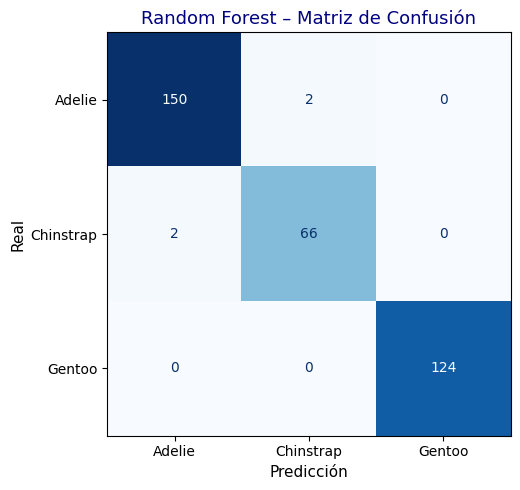

In [20]:
cm = confusion_matrix(y_true_acum, y_pred_acum)
print(cm)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_true_acum,
                                        y_pred_acum,
                                        ax = ax,
                                         colorbar=False,
                                      cmap="Blues"
                                          )
ax.set_title("Random Forest – Matriz de Confusión", fontsize=13, color = "navy")
ax.set_xlabel("Predicción", fontsize=11)
ax.set_ylabel("Real", fontsize=11)

plt.tight_layout()
plt.savefig("01_Matriz_Random_Forest.png", dpi=150)
plt.show()
plt.close()

In [22]:
print(classification_report(y_true_acum, y_pred_acum))

              precision    recall  f1-score   support

      Adelie       0.99      0.99      0.99       152
   Chinstrap       0.97      0.97      0.97        68
      Gentoo       1.00      1.00      1.00       124

    accuracy                           0.99       344
   macro avg       0.99      0.99      0.99       344
weighted avg       0.99      0.99      0.99       344



In [23]:
print("\n=== Métricas detalladas ===")
print(f"Accuracy:           {accuracy_score(y_true_acum, y_pred_acum):.4f}")
print(f"Precision (macro):  {precision_score(y_true_acum, y_pred_acum, average='macro'):.4f}")
print(f"Recall (macro):     {recall_score(y_true_acum, y_pred_acum, average='macro'):.4f}")
print(f"F1-Score (macro):   {f1_score(y_true_acum, y_pred_acum, average='macro'):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_true_acum, y_pred_acum):.4f}")

resultado_3 = {
    "accuracy":np.mean(accuracy_score(y_true_acum, y_pred_acum)),
    "precision":np.mean(precision_score(y_true_acum, y_pred_acum, average='macro')),
    "Recall (macro)":np.mean(recall_score(y_true_acum, y_pred_acum, average='macro')),
    "F1-Score (macro)":np.mean(f1_score(y_true_acum, y_pred_acum, average='macro')),
"Balanced Accuracy":np.mean(balanced_accuracy_score(y_true_acum, y_pred_acum))
}


=== Métricas detalladas ===
Accuracy:           0.9884
Precision (macro):  0.9858
Recall (macro):     0.9858
F1-Score (macro):   0.9858
Balanced Accuracy:  0.9858


### Importancia de las variables

In [24]:
importancia = best_rf2.named_steps['model'].feature_importances_

pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancia}).sort_values('Importancia', ascending = False)

,Variable,Importancia
1,Longitud_Pico_cm,0.311226
3,Longitud_Aleta_cm,0.232203
2,Profundidad_Pico_cm,0.160460
4,Masa_Corporal_kg,0.108318
6,Isla_Dream,0.091042
5,Isla_Biscoe,0.067994
7,Isla_Torgersen,0.020836
9,Sexo_Macho,0.003214
8,Sexo_Hembra,0.002648
0,Anio,0.002059


Podemos observar que la inclusión de más variables predictoras si aumentó la exactitud del modelo en 1.45 puntos porcentuales, esto sugiere que las varaibles incorporadas contienen información relevante. Sin embargo, como se ve ilustrado en la tabla de arriba, las variables que corresponden a variables corporales siguen representando la principal fuente de información para la clasificación de nuestra variable objetivo.